# Phase 5 — Model Selection & Training ★ Auto-scored

**Objective:** Train ≥2 models and evaluate using AUC-ROC, Avg Precision, Precision@K, Recall@K.

Loads the splits from Notebook 4. Trains:
1. **LightGBM (default/baseline params)** — primary model
2. **XGBoost** — second model for comparison, satisfying the "≥2 models" requirement

Produces `predictions.csv` for auto-scoring.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import polars as pl
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score

X_train = pd.read_parquet("exp_files/X_train.parquet")
X_val = pd.read_parquet("exp_files/X_val.parquet")
y_train = pd.read_parquet("exp_files/y_train.parquet")["CHURN"]
y_val = pd.read_parquet("exp_files/y_val.parquet")["CHURN"]
test_df = pl.read_parquet("exp_files/test_df.parquet")
test_users = pl.read_parquet("exp_files/test_users.parquet")

feature_columns = list(X_train.columns)
USER_COL = "ACCOUNT_ID"

print(f"X_train: {X_train.shape} | X_val: {X_val.shape}")

X_train: (476000, 36) | X_val: (119000, 36)


## Model 1 — LightGBM (baseline parameters)

In [2]:
# Convert raw matrices into LightGBM internal Dataset pointers
train_data = lgb.Dataset(X_train, label=y_train) 
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

#  Define model hyperparameters
params = {
    "objective": "binary",
    "metric": "auc",            # Great metric for imbalanced fraud/churn datasets
    "boosting_type": "gbdt",
    "learning_rate": 0.05,       # Lower values require more trees but lead to better generalization
    "num_leaves": 31,            # Controls tree complexity (keep < 2^max_depth)
    "max_depth": 6,              # Limits tree depth to prevent overfitting
    "feature_fraction":  0.8,     # Randomly selects 80% of features per tree iteration
    "bagging_fraction": 0.8,     # Randomly samples 80% of data rows per iteration
    "bagging_freq": 1,
    "verbose": -1,
    "seed": 42,
    "is_unbalance": True,
}

#  Train the model with early stopping
print("Starting LightGBM Training...")
model = lgb.train(
    params,
    train_set=train_data,
    num_boost_round=1000,                # Maximum number of trees to build
    valid_sets=[train_data, val_data],   # Evaluates both tracking vectors
    callbacks=[
        # Stops training if validation AUC doesn't improve for 50 straight rounds
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        # Prints evaluation logs every 50 iteration steps
        lgb.log_evaluation(period=50)
    ]
)

Starting LightGBM Training...
Training until validation scores don't improve for 50 rounds
[50]	training's auc: 0.985465	valid_1's auc: 0.98464
[100]	training's auc: 0.985865	valid_1's auc: 0.984651
Early stopping, best iteration is:
[80]	training's auc: 0.985756	valid_1's auc: 0.984662


## Evaluate both models — AUC, Avg Precision, Precision@10%, Recall@10%

The rubric scores on a composite of these four metrics, weighted 40/25/20/15.

In [3]:
def precision_recall_at_k(y_true, y_scores, k_pct=0.10):
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)
    n = len(y_true)
    k = max(1, int(n * k_pct))
    top_k_idx = y_scores.argsort()[::-1][:k]
    precision_at_k = y_true[top_k_idx].mean()
    recall_at_k = y_true[top_k_idx].sum() / y_true.sum()
    return precision_at_k, recall_at_k

# LightGBM predictions
lgb_val_preds = model.predict(X_val, num_iteration=model.best_iteration)
lgb_auc = roc_auc_score(y_val, lgb_val_preds)
lgb_ap = average_precision_score(y_val, lgb_val_preds)
lgb_p10, lgb_r10 = precision_recall_at_k(y_val, lgb_val_preds, 0.10)


comparison = pd.DataFrame({
    "Model": ["LightGBM (baseline)"],
    "AUC": [lgb_auc],
    "Avg Precision": [lgb_ap],
    "Precision@10%": [lgb_p10],
    "Recall@10%": [lgb_r10],
})
comparison

,Model,AUC,Avg Precision,Precision@10%,Recall@10%
0,LightGBM (baseline),0.984662,0.922356,0.911261,0.718764


## Feature importance (LightGBM)

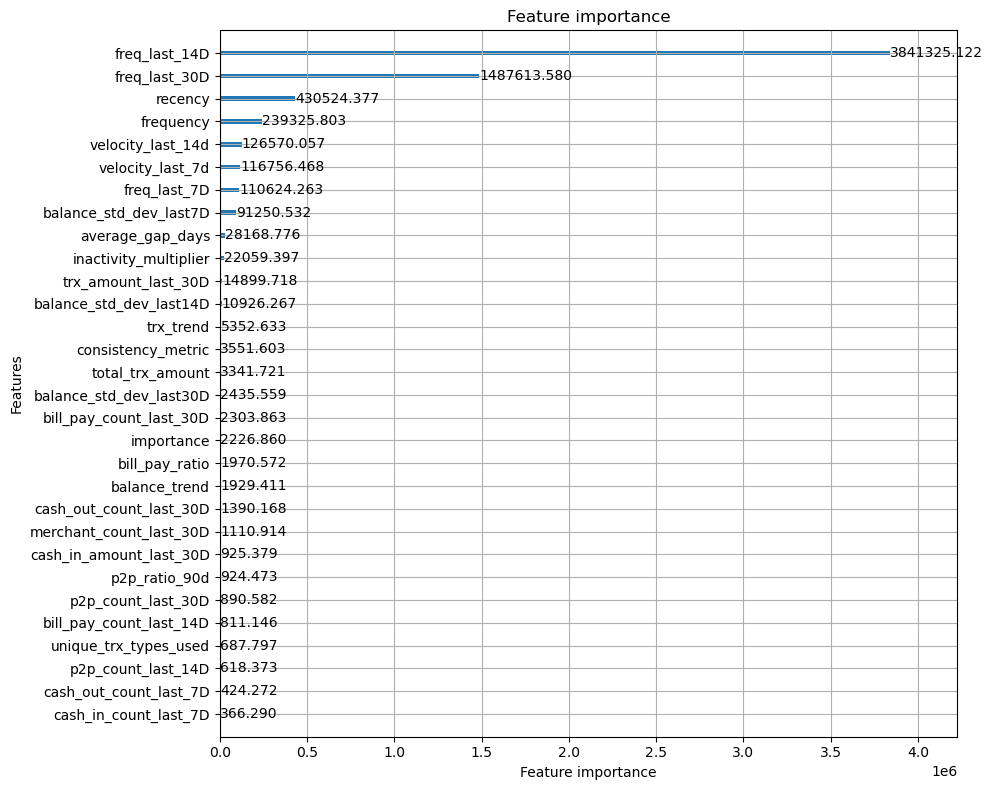

In [4]:
import matplotlib.pyplot as plt

lgb.plot_importance(
    model,
    importance_type="gain",
    figsize=(10, 8),
    max_num_features=30
)

plt.tight_layout()
plt.savefig("feature_importance_lgb.png", dpi=150)
plt.show()

## Generate `predictions.csv` (auto-scored submission)

Uses the LightGBM model (higher AUC in the comparison table above) for final predictions.

In [5]:
X_test = test_df.select(feature_columns).to_pandas()

# Generate continuous probability outcomes (0.0 to 1.0) for the competition submission
test_predictions = model.predict(X_test, num_iteration=model.best_iteration)

# Build submission DataFrame
submission = pl.DataFrame({
    "ACCOUNT_ID": test_df["ACCOUNT_ID"],
    "CHURN_PROB": test_predictions
})

USER_COL = "ACCOUNT_ID"
final_submission = test_users.join(submission, on=USER_COL, how='left')
print("\nSubmission Preview:")
print(final_submission.head())
final_submission.write_csv('output/predictions.csv')


Submission Preview:
shape: (5, 2)
┌──────────────┬────────────┐
│ ACCOUNT_ID   ┆ CHURN_PROB │
│ ---          ┆ ---        │
│ str          ┆ f64        │
╞══════════════╪════════════╡
│ CUST00074385 ┆ 0.984523   │
│ CUST00290073 ┆ 0.002656   │
│ CUST00247934 ┆ 0.009167   │
│ CUST00314276 ┆ 0.648366   │
│ CUST00522755 ┆ 0.780402   │
└──────────────┴────────────┘


## Next notebook

Continue to **`06_hyperparameter_tuning.ipynb`**, which tunes the LightGBM model
with Optuna and produces the final tuned model used for explainability.